### [Monte Carlo Simulation in Python to Make Data-Driven Decisions Under Uncertainty](https://drlee.io/stop-guessing-about-risk-use-monte-carlo-simulation-in-python-to-make-data-driven-decisions-under-37c563ed460e)

> The Fundamental Principle: Embracing Randomness to Reduce Uncertainty

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from scipy import stats
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(suppress=True, precision=4)

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

%autosave 10

Autosaving every 10 seconds


#### **Use Case 1: Investment Portfolio Risk Assessment**

In [2]:
initial_investment = 100000
num_simulations = 10000
num_days = 252
daily_mean = 0.0004
daily_std = 0.01
mean_return = daily_mean
std_return = daily_std

print(f"Historical Statistics:")
print(f"- Average Daily Return: {mean_return*100:.4f}%")
print(f"- Daily Volatility: {std_return*100:.4f}%")
print(f"- Annualized Return: {mean_return*252*100:.2f}%")
print(f"- Annualized Volatility: {std_return*np.sqrt(252)*100:.2f}%")

Historical Statistics:
- Average Daily Return: 0.0400%
- Daily Volatility: 1.0000%
- Annualized Return: 10.08%
- Annualized Volatility: 15.87%


In [3]:
portfolio_values = np.zeros((num_simulations, num_days + 1))
portfolio_values[:, 0] = initial_investment

print(f"\nRunning {num_simulations:,} simulations for {num_days} trading days...")
for sim in range(num_simulations):
  for day in range(1, num_days + 1):
    daily_return = np.random.normal(mean_return, std_return)
    portfolio_values[sim, day] = portfolio_values[sim, day-1] * (1 + daily_return)

final_values = portfolio_values[:, -1]


Running 10,000 simulations for 252 trading days...


In [4]:
percentiles = [5, 25, 50, 75, 95]
print("\nPORTFOLIO SIMULATION RESULTS (After 1 Year)")
print("-" * 80)
for p in percentiles:
  value = np.percentile(final_values, p)
  return_pct = ((value - initial_investment) / initial_investment) * 100
  print(f"{p}th Percentile: ${value:,.2f} ({return_pct:+.2f}% return)")

print(f"\nMean Final Value: ${final_values.mean():,.2f}")
print(f"Median Final Value: ${np.median(final_values):,.2f}")
print(f"Standard Deviation: ${final_values.std():,.2f}")

prob_loss = (final_values < initial_investment).sum() / num_simulations * 100
print(f"\nProbability of Loss: {prob_loss:.2f}%")

expected_return = ((final_values.mean() - initial_investment) / initial_investment) * 100
print(f"Expected Return: {expected_return:+.2f}%")

var_95 = initial_investment - np.percentile(final_values, 5)
print(f"\nValue at Risk (95% confidence): ${var_95:,.2f}")
print(f"(Maximum expected loss with 95% confidence)")


PORTFOLIO SIMULATION RESULTS (After 1 Year)
--------------------------------------------------------------------------------
5th Percentile: $83,811.68 (-16.19% return)
25th Percentile: $98,285.77 (-1.71% return)
50th Percentile: $109,080.22 (+9.08% return)
75th Percentile: $121,116.83 (+21.12% return)
95th Percentile: $141,226.63 (+41.23% return)

Mean Final Value: $110,445.88
Median Final Value: $109,080.22
Standard Deviation: $17,447.97

Probability of Loss: 28.22%
Expected Return: +10.45%

Value at Risk (95% confidence): $16,188.32
(Maximum expected loss with 95% confidence)


#### **Use Case 2: Software Project Timeline Risk Assessment**

In [5]:
tasks = {
  'Requirements Gathering': {'optimistic': 5, 'most_likely': 10, 'pessimistic': 20},
  'Design & Architecture': {'optimistic': 10, 'most_likely': 15, 'pessimistic': 25},
  'Backend Development': {'optimistic': 20, 'most_likely': 30, 'pessimistic': 50},
  'Frontend Development': {'optimistic': 15, 'most_likely': 25, 'pessimistic': 40},
  'Integration & Testing': {'optimistic': 10, 'most_likely': 15, 'pessimistic': 30},
  'UAT & Bug Fixes': {'optimistic': 5, 'most_likely': 10, 'pessimistic': 20},
  'Deployment & Training': {'optimistic': 3, 'most_likely': 5, 'pessimistic': 10}
}

print("\nProject Tasks with Time Estimates (in days):")
print(f"{'Task':<30} {'Optimistic':<12} {'Most Likely':<12} {'Pessimistic':<12}")
for task, estimates in tasks.items():
  print(f"{task:<30} {estimates['optimistic']:<12} {estimates['most_likely']:<12} {estimates['pessimistic']:<12}")


Project Tasks with Time Estimates (in days):
Task                           Optimistic   Most Likely  Pessimistic 
Requirements Gathering         5            10           20          
Design & Architecture          10           15           25          
Backend Development            20           30           50          
Frontend Development           15           25           40          
Integration & Testing          10           15           30          
UAT & Bug Fixes                5            10           20          
Deployment & Training          3            5            10          


In [6]:
num_project_sims = 10000
project_durations = []
print(f"\nRunning {num_project_sims:,} project timeline simulations...")
for sim in range(num_project_sims):
  total_duration = 0
  for task, estimates in tasks.items():
    o = estimates['optimistic']
    m = estimates['most_likely']
    p = estimates['pessimistic']
    task_duration = np.random.triangular(o, m, p)
    total_duration += task_duration
  project_durations.append(total_duration)
project_durations = np.array(project_durations)
traditional_estimate = sum(task['most_likely'] for task in tasks.values())


Running 10,000 project timeline simulations...


In [7]:
print("\nPROJECT TIMELINE SIMULATION RESULTS")
print(f"\nTraditional Estimate (Sum of Most Likely): {traditional_estimate} days")

print("\nMonte Carlo Simulation Results:")

percentiles_project = [10, 25, 50, 75, 90, 95]
for p in percentiles_project:
  days = np.percentile(project_durations, p)
  print(f"{p}th Percentile: {days:.1f} days ({days/traditional_estimate*100:.1f}% of traditional estimate)")

print(f"\nMean Duration: {project_durations.mean():.1f} days")
print(f"Median Duration: {np.median(project_durations):.1f} days")
print(f"Standard Deviation: {project_durations.std():.1f} days")

prob_on_time = (project_durations <= traditional_estimate).sum() / num_project_sims * 100
print(f"\nProbability of Meeting Traditional Estimate: {prob_on_time:.1f}%")

print("\nRecommended Timeline by Confidence Level:")
for confidence in [50, 75, 90, 95]:
  recommended_days = np.percentile(project_durations, confidence)
  buffer = recommended_days - traditional_estimate
  print(f"- {confidence}% Confidence: {recommended_days:.1f} days (add {buffer:.1f} day buffer)")


PROJECT TIMELINE SIMULATION RESULTS

Traditional Estimate (Sum of Most Likely): 110 days

Monte Carlo Simulation Results:
10th Percentile: 110.5 days (100.5% of traditional estimate)
25th Percentile: 116.7 days (106.1% of traditional estimate)
50th Percentile: 123.9 days (112.7% of traditional estimate)
75th Percentile: 131.4 days (119.5% of traditional estimate)
90th Percentile: 138.0 days (125.4% of traditional estimate)
95th Percentile: 142.2 days (129.3% of traditional estimate)

Mean Duration: 124.2 days
Median Duration: 123.9 days
Standard Deviation: 10.7 days

Probability of Meeting Traditional Estimate: 9.0%

Recommended Timeline by Confidence Level:
- 50% Confidence: 123.9 days (add 13.9 day buffer)
- 75% Confidence: 131.4 days (add 21.4 day buffer)
- 90% Confidence: 138.0 days (add 28.0 day buffer)
- 95% Confidence: 142.2 days (add 32.2 day buffer)


#### **Use Case 3: Apple Stock (AAPL) Risk Assessment Using yfinance**

In [8]:
current_price = 175.00
daily_mean = 0.0012
daily_std = 0.0165
annual_return = daily_mean * 252
annual_volatility = daily_std * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print(f"AAPL Current Price: ${current_price:.2f}")
print(f"\nHistorical Statistics (3-year period):")
print(f"- Average Daily Return: {daily_mean*100:.4f}%")
print(f"- Daily Volatility: {daily_std*100:.4f}%")
print(f"- Annualized Return: {annual_return*100:.2f}%")
print(f"- Annualized Volatility: {annual_volatility*100:.2f}%")
print(f"- Sharpe Ratio: {sharpe_ratio:.2f}")

AAPL Current Price: $175.00

Historical Statistics (3-year period):
- Average Daily Return: 0.1200%
- Daily Volatility: 1.6500%
- Annualized Return: 30.24%
- Annualized Volatility: 26.19%
- Sharpe Ratio: 1.15


[*********************100%***********************]  1 of 1 completed



AAPL Stock Analysis
Current Price: $260.48
Analysis Period: 2021-11-03 to 2026-04-11

---------------------Daily Statistics:----------------------
  Average Daily Return: 0.0666%
  Daily Volatility (Std Dev): 1.7799%

--------------------Annualized Metrics:---------------------
  Annualized Return: 16.79%
  Annualized Volatility: 28.26%
  Sharpe Ratio: 0.59

-------------------Additional Statistics:-------------------
  Minimum Daily Return: -9.25%
  Maximum Daily Return: 15.33%
  Median Daily Return: 0.0899%
  Skewness: 0.497
  Kurtosis: 6.977

---------------------Price Performance:---------------------
  Starting Price: $148.02
  Ending Price: $260.48
  Total Return: 75.97%



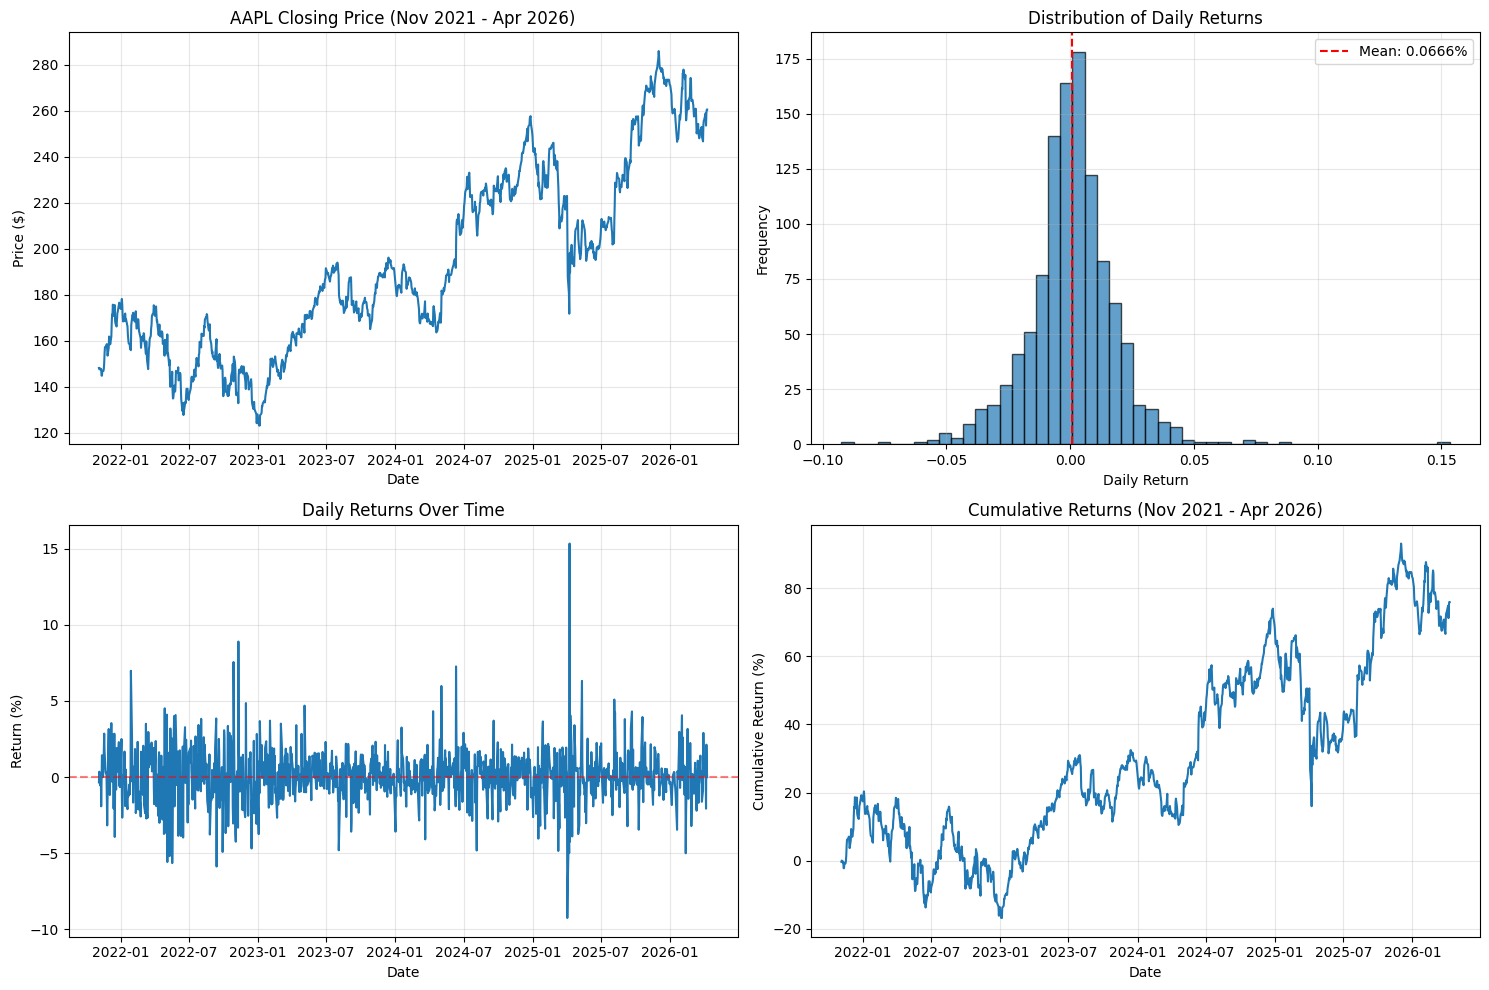

In [9]:
# Download historical data - specific date range
print("Downloading AAPL historical data...")
start_date = datetime(2021, 11, 3)  # 3 years ago from Nov 3, 2024
end_date = datetime.now()            # Today
aapl = yf.download('AAPL', start=start_date, end=end_date)

# Calculate returns
aapl['Returns'] = aapl['Close'].pct_change()
daily_returns = aapl['Returns'].dropna()

# Calculate statistics from actual data
daily_mean = daily_returns.mean()
daily_std = daily_returns.std()
current_price = float(aapl['Close'].iloc[-1])  # Convert to float

# Annualized metrics
annual_return = daily_mean * 252
annual_volatility = daily_std * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

# Display results
print(f"\n{'='*60}")
print(f"AAPL Stock Analysis")
print(f"{'='*60}")
print(f"Current Price: ${current_price:.2f}")
print(f"Analysis Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"\n{'Daily Statistics:':-^60}")
print(f"  Average Daily Return: {daily_mean*100:.4f}%")
print(f"  Daily Volatility (Std Dev): {daily_std*100:.4f}%")
print(f"\n{'Annualized Metrics:':-^60}")
print(f"  Annualized Return: {annual_return*100:.2f}%")
print(f"  Annualized Volatility: {annual_volatility*100:.2f}%")
print(f"  Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"\n{'Additional Statistics:':-^60}")
print(f"  Minimum Daily Return: {daily_returns.min()*100:.2f}%")
print(f"  Maximum Daily Return: {daily_returns.max()*100:.2f}%")
print(f"  Median Daily Return: {daily_returns.median()*100:.4f}%")
print(f"  Skewness: {daily_returns.skew():.3f}")
print(f"  Kurtosis: {daily_returns.kurtosis():.3f}")

print(f"\n{'Price Performance:':-^60}")
start_price = float(aapl['Close'].iloc[0])  # Convert to float
total_return = ((current_price - start_price) / start_price) * 100
print(f"  Starting Price: ${start_price:.2f}")
print(f"  Ending Price: ${current_price:.2f}")
print(f"  Total Return: {total_return:.2f}%")

print(f"{'='*60}\n")

# Optional: Visualize the data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price chart
axes[0, 0].plot(aapl.index, aapl['Close'])
axes[0, 0].set_title(f'AAPL Closing Price ({start_date.strftime("%b %Y")} - {end_date.strftime("%b %Y")})')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Returns distribution
axes[0, 1].hist(daily_returns, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(daily_mean, color='red', linestyle='--', label=f'Mean: {daily_mean*100:.4f}%')
axes[0, 1].set_title('Distribution of Daily Returns')
axes[0, 1].set_xlabel('Daily Return')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Returns over time
axes[1, 0].plot(daily_returns.index, daily_returns * 100)
axes[1, 0].set_title('Daily Returns Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Return (%)')
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)

# Cumulative returns
cumulative_returns = (1 + daily_returns).cumprod()
axes[1, 1].plot(cumulative_returns.index, (cumulative_returns - 1) * 100)
axes[1, 1].set_title(f'Cumulative Returns ({start_date.strftime("%b %Y")} - {end_date.strftime("%b %Y")})')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Cumulative Return (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Monte Carlo Simulation - Investment Scenario
- Buying 100 shares at $260.48
- Initial Investment: $26,048.00
- Projection Period: 252 trading days (1 year)
- Number of Simulations: 10,000

Running 10,000 simulations...

--------------------Simulation Results:---------------------

Expected Final Stock Price:
  Mean: $308.27
  Median: $295.58
  Std Dev: $88.65

Expected Portfolio Value:
  Mean: $30,827.47
  Median: $29,557.68

Expected Returns:
  Mean Return: 18.35%
  Median Return: 13.47%

Percentile Analysis (Final Portfolio Value):
  5th percentile: $18,735.31 (-28.07%)
  25th percentile: $24,563.04 (-5.70%)
  50th percentile: $29,557.68 (+13.47%)
  75th percentile: $35,777.61 (+37.35%)
  95th percentile: $47,244.42 (+81.37%)

Risk Assessment:
  Probability of Profit: 67.89%
  Probability of Loss: 32.11%

Value at Risk (VaR) - 5% worst case:
  Portfolio Value: $18,735.31
  Potential Loss: $7,312.69



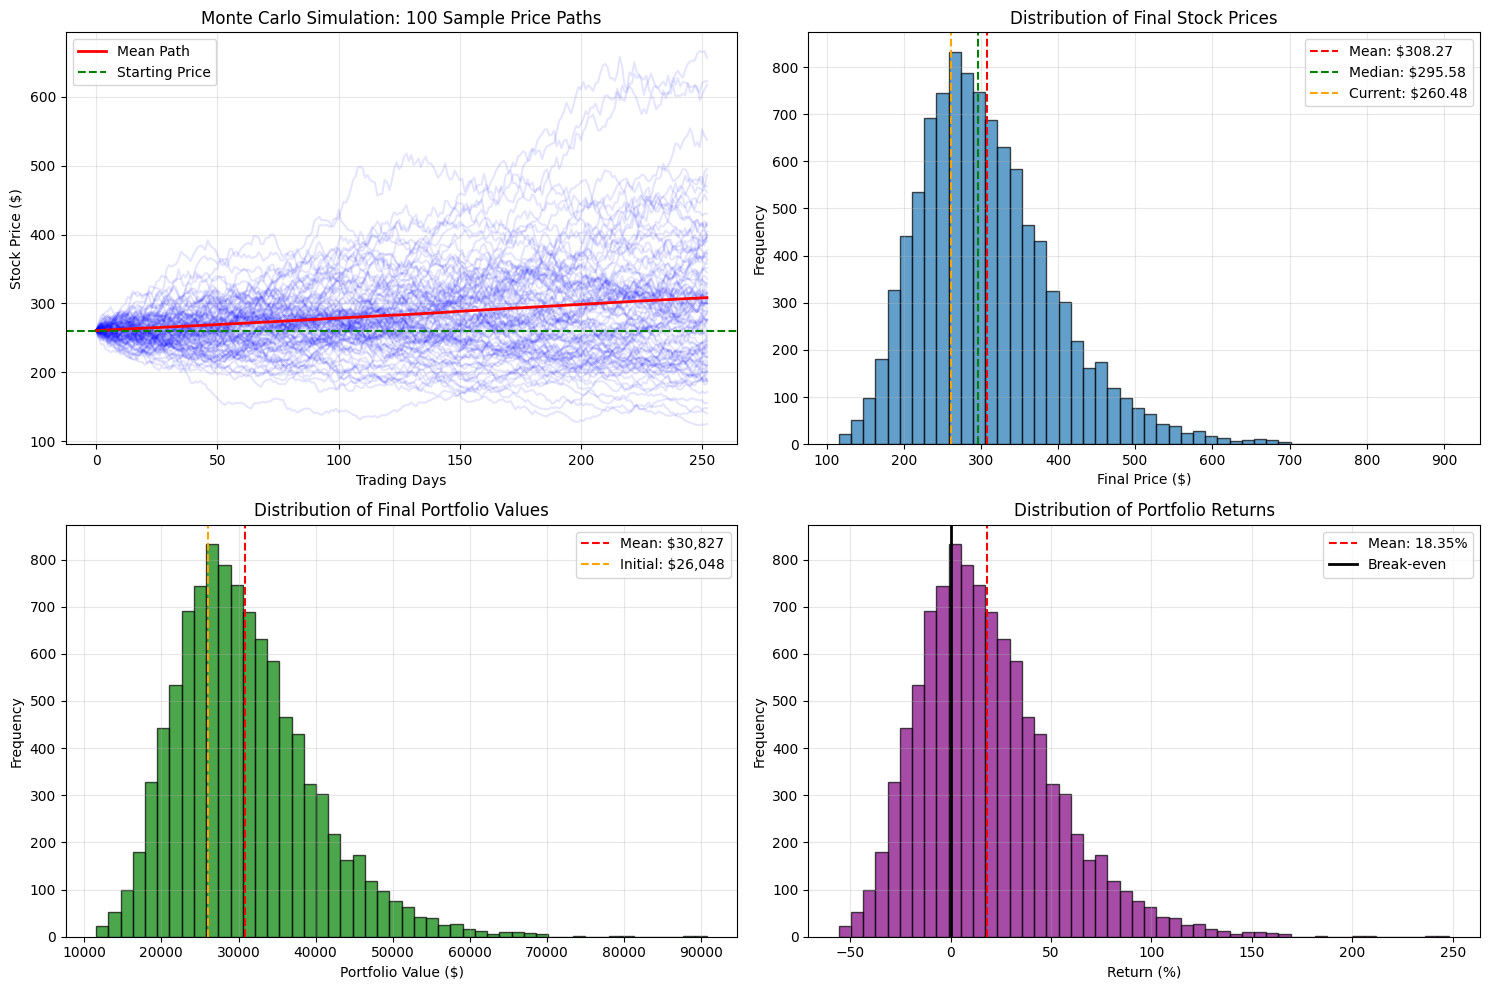

In [10]:
# Make sure these variables are defined from the previous code
initial_shares = 100
initial_investment = current_price * initial_shares
num_simulations = 10000
num_days = 252

print(f"\n{'='*60}")
print(f"Monte Carlo Simulation - Investment Scenario")
print(f"{'='*60}")
print(f"- Buying {initial_shares} shares at ${current_price:.2f}")
print(f"- Initial Investment: ${initial_investment:,.2f}")
print(f"- Projection Period: {num_days} trading days (1 year)")
print(f"- Number of Simulations: {num_simulations:,}")

# Initialize the stock price matrix
stock_prices = np.zeros((num_simulations, num_days + 1))
stock_prices[:, 0] = current_price

# Run Monte Carlo simulations
print(f"\nRunning {num_simulations:,} simulations...")
for sim in range(num_simulations):
  for day in range(1, num_days + 1):
    random_shock = np.random.normal(0, 1)
    drift = daily_mean - 0.5 * daily_std**2
    stock_prices[sim, day] = stock_prices[sim, day-1] * np.exp(drift + daily_std * random_shock)

# Calculate final results
final_prices = stock_prices[:, -1]
final_values = final_prices * initial_shares

# Calculate statistics
mean_final_price = final_prices.mean()
median_final_price = np.median(final_prices)
std_final_price = final_prices.std()
mean_final_value = final_values.mean()
median_final_value = np.median(final_values)

# Calculate returns
mean_return = ((mean_final_value - initial_investment) / initial_investment) * 100
median_return = ((median_final_value - initial_investment) / initial_investment) * 100

# Calculate percentiles
percentiles = [5, 25, 50, 75, 95]
price_percentiles = np.percentile(final_prices, percentiles)
value_percentiles = np.percentile(final_values, percentiles)

# Display results
print(f"\n{'Simulation Results:':-^60}")
print(f"\n{'Expected Final Stock Price:'}")
print(f"  Mean: ${mean_final_price:.2f}")
print(f"  Median: ${median_final_price:.2f}")
print(f"  Std Dev: ${std_final_price:.2f}")

print(f"\n{'Expected Portfolio Value:'}")
print(f"  Mean: ${mean_final_value:,.2f}")
print(f"  Median: ${median_final_value:,.2f}")

print(f"\n{'Expected Returns:'}")
print(f"  Mean Return: {mean_return:.2f}%")
print(f"  Median Return: {median_return:.2f}%")

print(f"\n{'Percentile Analysis (Final Portfolio Value):'}")
for i, p in enumerate(percentiles):
  value = value_percentiles[i]
  return_pct = ((value - initial_investment) / initial_investment) * 100
  print(f"  {p}th percentile: ${value:,.2f} ({return_pct:+.2f}%)")

# Calculate probability of profit
prob_profit = (final_values > initial_investment).sum() / num_simulations * 100
prob_loss = 100 - prob_profit
print(f"\n{'Risk Assessment:'}")
print(f"  Probability of Profit: {prob_profit:.2f}%")
print(f"  Probability of Loss: {prob_loss:.2f}%")

# Value at Risk (VaR) - 5% worst case
var_5 = value_percentiles[0]
var_loss = initial_investment - var_5
print(f"\n{'Value at Risk (VaR) - 5% worst case:'}")
print(f"  Portfolio Value: ${var_5:,.2f}")
print(f"  Potential Loss: ${var_loss:,.2f}")

print(f"{'='*60}\n")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot sample paths
sample_size = 100
for i in range(sample_size):
  axes[0, 0].plot(stock_prices[i], alpha=0.1, color='blue')
axes[0, 0].plot(stock_prices.mean(axis=0), color='red', linewidth=2, label='Mean Path')
axes[0, 0].axhline(current_price, color='green', linestyle='--', label='Starting Price')
axes[0, 0].set_title(f'Monte Carlo Simulation: {sample_size} Sample Price Paths')
axes[0, 0].set_xlabel('Trading Days')
axes[0, 0].set_ylabel('Stock Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution of final prices
axes[0, 1].hist(final_prices, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(mean_final_price, color='red', linestyle='--', label=f'Mean: ${mean_final_price:.2f}')
axes[0, 1].axvline(median_final_price, color='green', linestyle='--', label=f'Median: ${median_final_price:.2f}')
axes[0, 1].axvline(current_price, color='orange', linestyle='--', label=f'Current: ${current_price:.2f}')
axes[0, 1].set_title('Distribution of Final Stock Prices')
axes[0, 1].set_xlabel('Final Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution of final portfolio values
axes[1, 0].hist(final_values, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(mean_final_value, color='red', linestyle='--', label=f'Mean: ${mean_final_value:,.0f}')
axes[1, 0].axvline(initial_investment, color='orange', linestyle='--', label=f'Initial: ${initial_investment:,.0f}')
axes[1, 0].set_title('Distribution of Final Portfolio Values')
axes[1, 0].set_xlabel('Portfolio Value ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Returns distribution
returns = ((final_values - initial_investment) / initial_investment) * 100
axes[1, 1].hist(returns, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(mean_return, color='red', linestyle='--', label=f'Mean: {mean_return:.2f}%')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=2, label='Break-even')
axes[1, 1].set_title('Distribution of Portfolio Returns')
axes[1, 1].set_xlabel('Return (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Expected value based on Geometric Brownian Motion: E[V_t] = V_0 * exp(mu * t)
# where mu is the annualized return (daily_mean * 252)
expected_value = initial_investment * np.exp(daily_mean * num_days)

spy_annual_return = 0.10
spy_final_value = initial_investment * (1 + spy_annual_return)
qqq_annual_return = 0.15
qqq_final_value = initial_investment * (1 + qqq_annual_return)
prob_beat_spy = (final_values > spy_final_value).sum() / num_simulations * 100
prob_beat_qqq = (final_values > qqq_final_value).sum() / num_simulations * 100

print(f"\nComparative Analysis:")
print(f"Holding Cash (0%): ${initial_investment:,.2f}")
print(f"S&P 500 (10%): ${spy_final_value:,.2f}")
print(f"Nasdaq 100 (15%): ${qqq_final_value:,.2f}")
print(f"AAPL Expected (Theoretical): ${expected_value:,.2f}")
print(f"AAPL Mean (Simulated): ${final_values.mean():,.2f}")

print(f"\nProbability AAPL Outperforms:")
print(f"- S&P 500: {prob_beat_spy:.1f}%")
print(f"- Nasdaq 100: {prob_beat_qqq:.1f}%")

max_drawdowns = []
for sim in range(num_simulations):
  cumulative_max = np.maximum.accumulate(stock_prices[sim])
  drawdown = (stock_prices[sim] - cumulative_max) / cumulative_max
  max_drawdowns.append(drawdown.min())
max_drawdowns = np.array(max_drawdowns)

print(f"\nMaximum Drawdown Analysis:")
print(f"- Expected Max Drawdown: {max_drawdowns.mean()*100:.2f}%")
print(f"- 95th Percentile: {np.percentile(max_drawdowns, 95)*100:.2f}%")


Comparative Analysis:
Holding Cash (0%): $26,048.00
S&P 500 (10%): $28,652.80
Nasdaq 100 (15%): $29,955.20
AAPL Expected (Theoretical): $30,810.07
AAPL Mean (Simulated): $30,827.47

Probability AAPL Outperforms:
- S&P 500: 54.3%
- Nasdaq 100: 48.1%

Maximum Drawdown Analysis:
- Expected Max Drawdown: -24.21%
- 95th Percentile: -12.86%
